# EDA for Urban Air Pollution Challenge on Zindi

S.M.O.G (Statistical Moddeling of Orbital Gases) 💨

Problem: Ground-based air quality sensors are expensive and geographically sparse across Africa. This data gap hinders the real-time tracking of PM2.5​, a pollutant critical to public health and respiratory safety.

Value of Product: Utilizing satellite imagery and weather data to estimate air quality provides a cost-effective alternative to physical hardware. It enables governments to issue health alerts and design urban policies based on localized pollution insights.

Prediction: Daily PM2.5​ concentration levels.

Evaluation Metric: 
RMSE (Primary): Penalizes large deviations. This is vital because under-predicting dangerous pollution spikes could lead to missed public health warnings.
MAE (Secondary): Provides a baseline for average error and helps identify if the model is being skewed by outliers or extreme weather events.

# Importing Packages

In [22]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from function import *

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

RSEED=42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Importing the Data

In [23]:
# Import diabetes data
df = pd.read_csv('./../Data/Train.csv')
df.head()

,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,11.000000,60.200001,...,38.593017,-61.752587,22.363665,1793.793579,3227.855469,0.010579,74.481049,37.501499,-62.142639,22.545118
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,14.600000,48.799999,...,59.624912,-67.693509,28.614804,1789.960449,3384.226562,0.015104,75.630043,55.657486,-53.868134,19.293652
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,8.0,56.0,1181.96,96,16.400000,33.400002,...,49.839714,-78.342701,34.296977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,010Q650 X 2020-01-05,2020-01-05,010Q650,49.0,10.0,55.0,1113.67,96,6.911948,21.300001,...,29.181258,-73.896588,30.545446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,010Q650 X 2020-01-06,2020-01-06,010Q650,21.0,9.0,52.0,1164.82,95,13.900001,44.700001,...,0.797294,-68.612480,26.899694,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30557 entries, 0 to 30556
Data columns (total 82 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      30557 non-null  object 
 1   Date                                                 30557 non-null  object 
 2   Place_ID                                             30557 non-null  object 
 3   target                                               30557 non-null  float64
 4   target_min                                           30557 non-null  float64
 5   target_max                                           30557 non-null  float64
 6   target_variance                                      30557 non-null  float64
 7   target_count                                         30557 non-null  int64  
 8   precipitable_water_entire_atmosphere                 30557 non-nul

In [25]:
df.isnull().sum()

Place_ID X Date                     0
Date                                0
Place_ID                            0
target                              0
target_min                          0
                                ...  
L3_CH4_aerosol_optical_depth    24765
L3_CH4_sensor_azimuth_angle     24765
L3_CH4_sensor_zenith_angle      24765
L3_CH4_solar_azimuth_angle      24765
L3_CH4_solar_zenith_angle       24765
Length: 82, dtype: int64

# EDA 1

Dropping the target variables we will not use to not leak data. Also drop the CH4 data since it is missing close to 80% of the data

In [26]:
cols_to_drop = [
    "target_",
    "ch4"
]


df = drop_features(df, cols_to_drop)
df.head()

Dropped 11 columns. New shape: (30557, 71)


,Place_ID X Date,Date,Place_ID,target,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,...,L3_AER_AI_solar_zenith_angle,L3_SO2_SO2_column_number_density,L3_SO2_SO2_column_number_density_amf,L3_SO2_SO2_slant_column_number_density,L3_SO2_absorbing_aerosol_index,L3_SO2_cloud_fraction,L3_SO2_sensor_azimuth_angle,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,11.000000,60.200001,0.00804,18.516840,1.996377,-1.227395,...,22.358167,-0.000127,0.312521,-0.000040,-1.861476,0.000000,76.536426,38.593017,-61.752587,22.363665
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,14.600000,48.799999,0.00839,22.546533,3.330430,-1.188108,...,28.614804,0.000150,0.433957,0.000050,-1.452612,0.059433,-14.708036,59.624912,-67.693509,28.614804
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,16.400000,33.400002,0.00750,27.031030,5.065727,3.500559,...,34.296977,0.000150,0.356925,0.000053,-1.572950,0.082063,-105.201338,49.839714,-78.342701,34.296977
3,010Q650 X 2020-01-05,2020-01-05,010Q650,49.0,6.911948,21.300001,0.00391,23.971857,3.004001,1.099468,...,30.545393,0.000227,0.584522,0.000110,-1.239317,0.121261,-104.334066,29.181258,-73.896588,30.545446
4,010Q650 X 2020-01-06,2020-01-06,010Q650,21.0,13.900001,44.700001,0.00535,16.816309,2.621787,2.670559,...,26.899694,0.000390,0.408047,0.000159,0.202489,0.037919,58.850179,0.797294,-68.612480,26.899694


## Checking for entrys per Place_ID 

In [27]:
df['Place_ID'].value_counts()

Place_ID
010Q650    94
JSXAVKO    94
I5RGE5G    94
I6718VY    94
I6VIR8R    94
           ..
LKE9VQB    41
S91MBTB    29
6KAHP8X    12
MJSB8K5     7
5IUK9TG     3
Name: count, Length: 340, dtype: int64

In [28]:
df['Date'].value_counts().sort_index()

Date
2020-01-02    324
2020-01-03    327
2020-01-04    329
2020-01-05    331
2020-01-06    327
             ... 
2020-03-31    326
2020-04-01    328
2020-04-02    329
2020-04-03    330
2020-04-04    323
Name: count, Length: 94, dtype: int64

# Splitting the dataset


In [ ]:
y = df["target"] 
X = df.drop("target", axis=1)

# Split into Train, Val, and Test (60/20/20)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=RSEED)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=RSEED)

Train shape: (18333, 71)
Val shape:   (6112, 71)
Test shape:  (6112, 71)


## Interpolating based on same Place_ID

In [ ]:

X_train_clean, train_stats = impute_full_pipeline(X_train)

# Transform Val & Test using Train stats (Prevents Data Leakage)
X_val_clean, _ = impute_full_pipeline(X_val, fit_stats=train_stats)
X_test_clean, _ = impute_full_pipeline(X_test, fit_stats=train_stats)

# Step C: Recombine features and targets into final DataFrames
train_df = pd.concat([X_train_clean, y_train], axis=1)
val_df   = pd.concat([X_val_clean, y_val], axis=1)
test_df  = pd.concat([X_test_clean, y_test], axis=1)

# --- 4. VERIFICATION ---
print(f"Final Train Shape: {train_df.shape} | NaNs left: {train_df.isna().sum().sum()}")
print(f"Final Val Shape:   {val_df.shape}   | NaNs left: {val_df.isna().sum().sum()}")
print(f"Final Test Shape:  {test_df.shape}  | NaNs left: {test_df.isna().sum().sum()}")

Final Train Shape: (18333, 71) | NaNs left: 0
Final Val Shape:   (6112, 71)   | NaNs left: 0
Final Test Shape:  (6112, 71)  | NaNs left: 0


### Checking if there are any more nan values 

In [36]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18333 entries, 26358 to 18540
Data columns (total 71 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      18333 non-null  object 
 1   Date                                                 18333 non-null  object 
 2   Place_ID                                             18333 non-null  object 
 3   precipitable_water_entire_atmosphere                 18333 non-null  float64
 4   relative_humidity_2m_above_ground                    18333 non-null  float64
 5   specific_humidity_2m_above_ground                    18333 non-null  float64
 6   temperature_2m_above_ground                          18333 non-null  float64
 7   u_component_of_wind_10m_above_ground                 18333 non-null  float64
 8   v_component_of_wind_10m_above_ground                 18333 non-null

# Feature Engineering

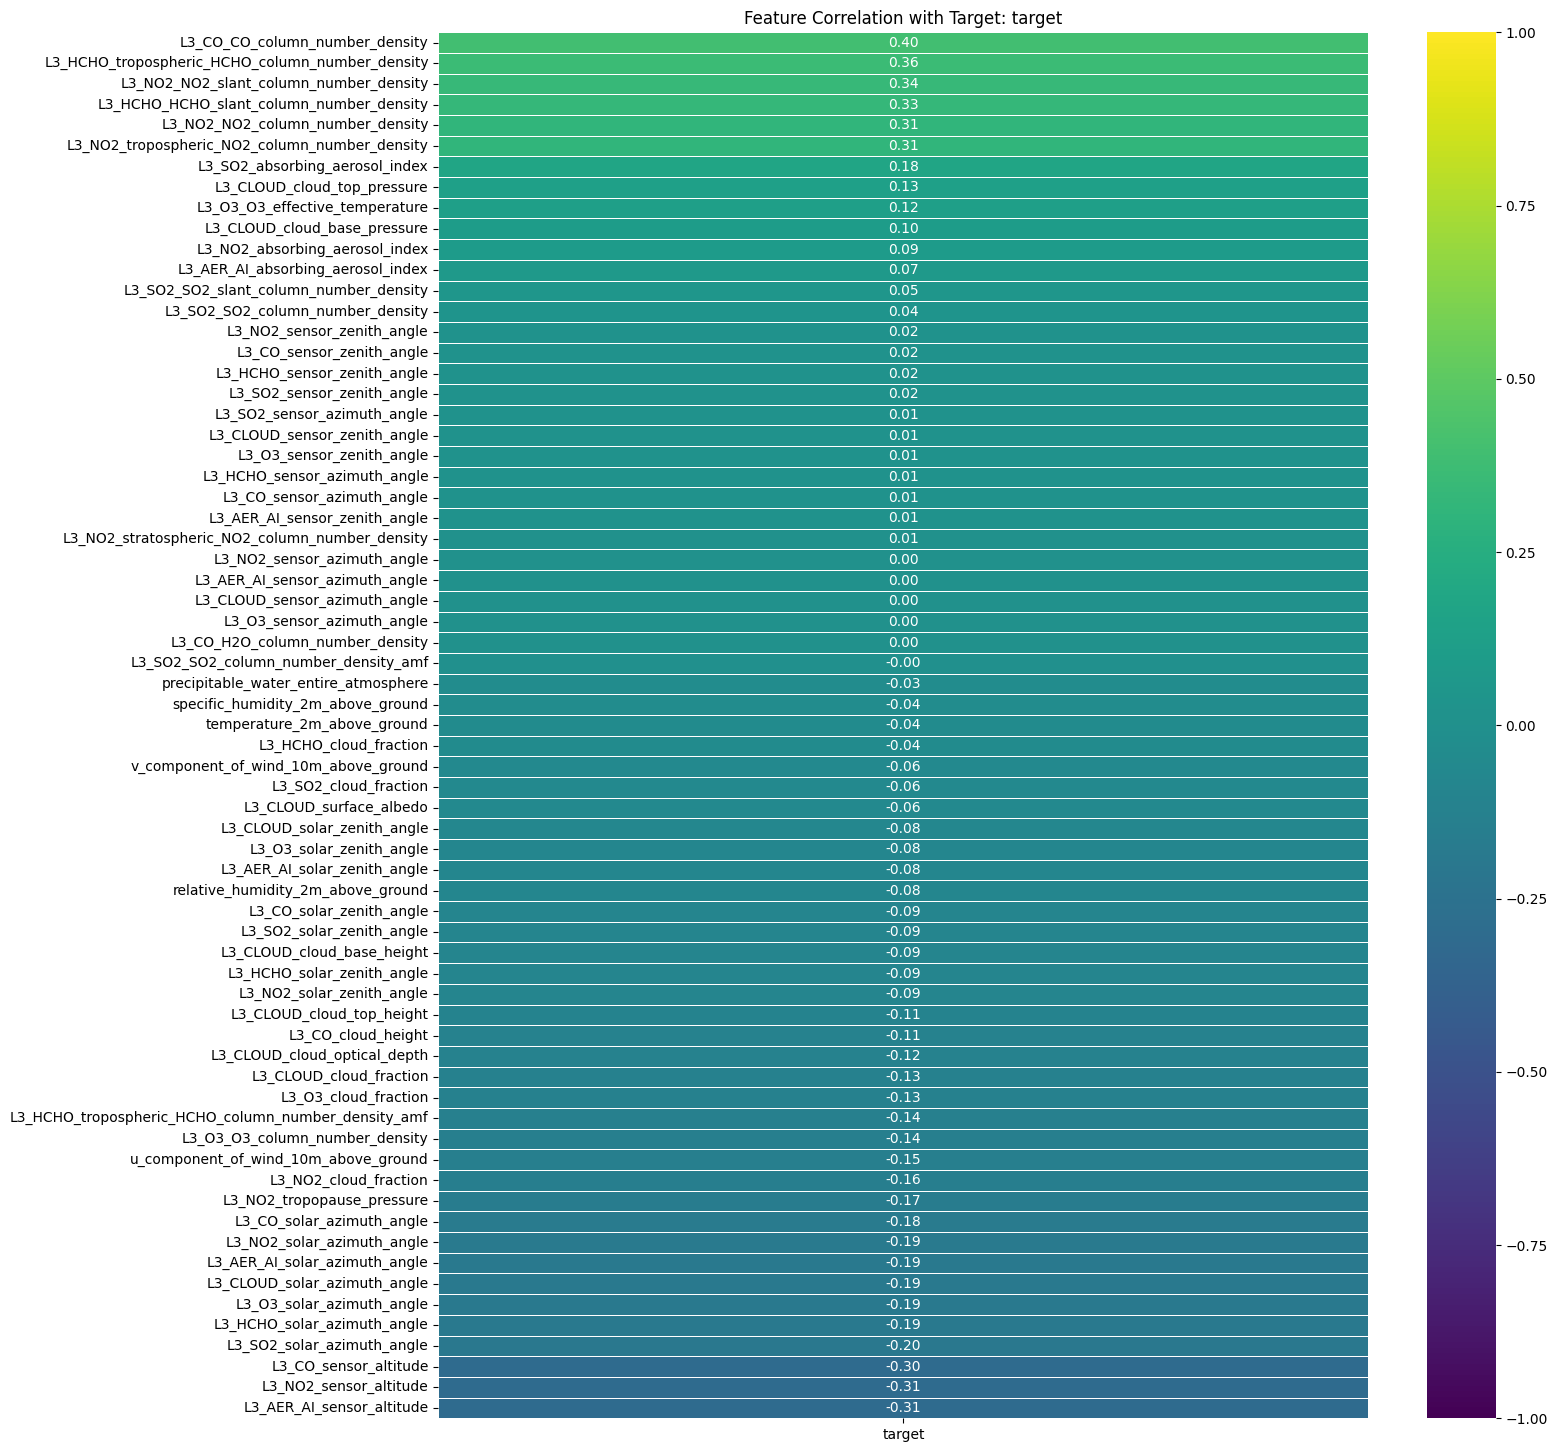

In [37]:
plot_target_correlation(train_df, "target")

In [38]:
train_df = relative_mean_angles(train_df)

Reduced features. New columns added: ['L3_SO2_SO2_slant_column_number_density', 'L3_SO2_absorbing_aerosol_index', 'L3_SO2_cloud_fraction', 'target', 'relative_azimuth', 'relative_zenith']


In [39]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18333 entries, 26358 to 18540
Data columns (total 45 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      18333 non-null  object 
 1   Date                                                 18333 non-null  object 
 2   Place_ID                                             18333 non-null  object 
 3   precipitable_water_entire_atmosphere                 18333 non-null  float64
 4   relative_humidity_2m_above_ground                    18333 non-null  float64
 5   specific_humidity_2m_above_ground                    18333 non-null  float64
 6   temperature_2m_above_ground                          18333 non-null  float64
 7   u_component_of_wind_10m_above_ground                 18333 non-null  float64
 8   v_component_of_wind_10m_above_ground                 18333 non-null

In [40]:
train_df = cloud_fraction_reduction(train_df)
train_df = sensor_altitude_reduction(train_df)
train_df = calculate_air_mass_factors(train_df)
train_df = calculate_atmospheric_indices(train_df)

In [41]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18333 entries, 26358 to 18540
Data columns (total 44 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      18333 non-null  object 
 1   Date                                                 18333 non-null  object 
 2   Place_ID                                             18333 non-null  object 
 3   precipitable_water_entire_atmosphere                 18333 non-null  float64
 4   relative_humidity_2m_above_ground                    18333 non-null  float64
 5   specific_humidity_2m_above_ground                    18333 non-null  float64
 6   temperature_2m_above_ground                          18333 non-null  float64
 7   u_component_of_wind_10m_above_ground                 18333 non-null  float64
 8   v_component_of_wind_10m_above_ground                 18333 non-null

In [42]:
cols_to_drop_2 = [
    'Place_ID X Date'
    "Date",
    "Place_ID",
    "L3_CLOUD_cloud_base_height",
    "L3_CLOUD_cloud_base_pressure"
]

train_df = drop_features(train_df, cols_to_drop_2)
train_df

Dropped 4 columns. New shape: (18333, 40)


,Date,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,L3_NO2_NO2_column_number_density,L3_NO2_NO2_slant_column_number_density,L3_NO2_absorbing_aerosol_index,...,target,relative_azimuth,relative_zenith,mean_cloud_fraction,mean_sensor_altitude,AMF_NO2,AMF_SO2_calc,AMF_HCHO_calc,NO2_Tropo_Ratio,Cloud_Thickness_Pressure
26358,2020-01-19,7.866667,91.133336,0.003837,1.530817,1.393659,0.987620,0.000145,0.000195,-0.656913,...,36.0,2.161235,19.291485,0.562150,834134.495130,1.348624,-0.050427,0.364292,0.443495,11399.539559
4754,2020-02-29,24.200001,86.000000,0.005560,7.731561,-2.534685,-1.431047,0.000114,0.000180,-0.413192,...,70.0,83.754525,27.883494,0.691234,830479.735595,1.583896,0.243914,0.413155,1.077672,10664.332354
11008,2020-01-10,7.100000,90.400002,0.004250,1.802179,1.552092,0.893457,0.000047,0.000124,-1.092711,...,17.0,241.454460,24.562907,0.600703,832828.464149,2.624532,-0.080116,0.839857,0.309260,9136.347518
19573,2020-02-22,38.100002,60.000000,0.012044,22.750818,-2.396411,0.467820,0.000064,0.000129,-1.164566,...,80.0,36.495395,6.574886,0.461834,837079.767192,2.032020,1.269849,1.013662,0.782382,3852.747062
11232,2020-02-18,9.235486,77.599998,0.004154,4.891229,8.095952,2.213753,0.000065,0.000115,-0.404625,...,29.0,31.576316,24.351794,0.658157,835318.658949,1.758874,0.187786,0.439079,0.354101,8161.365052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21856,2020-03-12,10.900001,75.700005,0.006889,10.264459,-0.404288,0.753560,0.000073,0.000174,-1.168069,...,102.0,43.498081,17.653233,0.082475,829891.212763,2.382480,0.447992,0.421625,0.390490,1131.257503
8679,2020-02-11,19.300000,42.442858,0.008064,24.219995,3.083621,-0.172889,0.000072,0.000154,-0.927198,...,54.0,45.751592,2.551801,0.071938,841548.521889,2.132183,0.376182,0.126478,0.207950,6831.230298
9831,2020-01-02,10.300000,84.300003,0.004620,5.456842,-0.033623,1.862605,0.000047,0.000125,-0.802731,...,13.0,210.077132,15.317456,0.666418,831686.390430,2.666436,0.336296,-0.418267,0.597693,10143.683993
14744,2020-02-17,14.366666,75.766665,0.005973,10.432286,-0.728250,-2.313820,0.000132,0.000267,-0.472217,...,25.0,59.617632,26.314670,0.653377,830940.979356,2.024677,1.796168,1.115783,1.432577,10008.128372


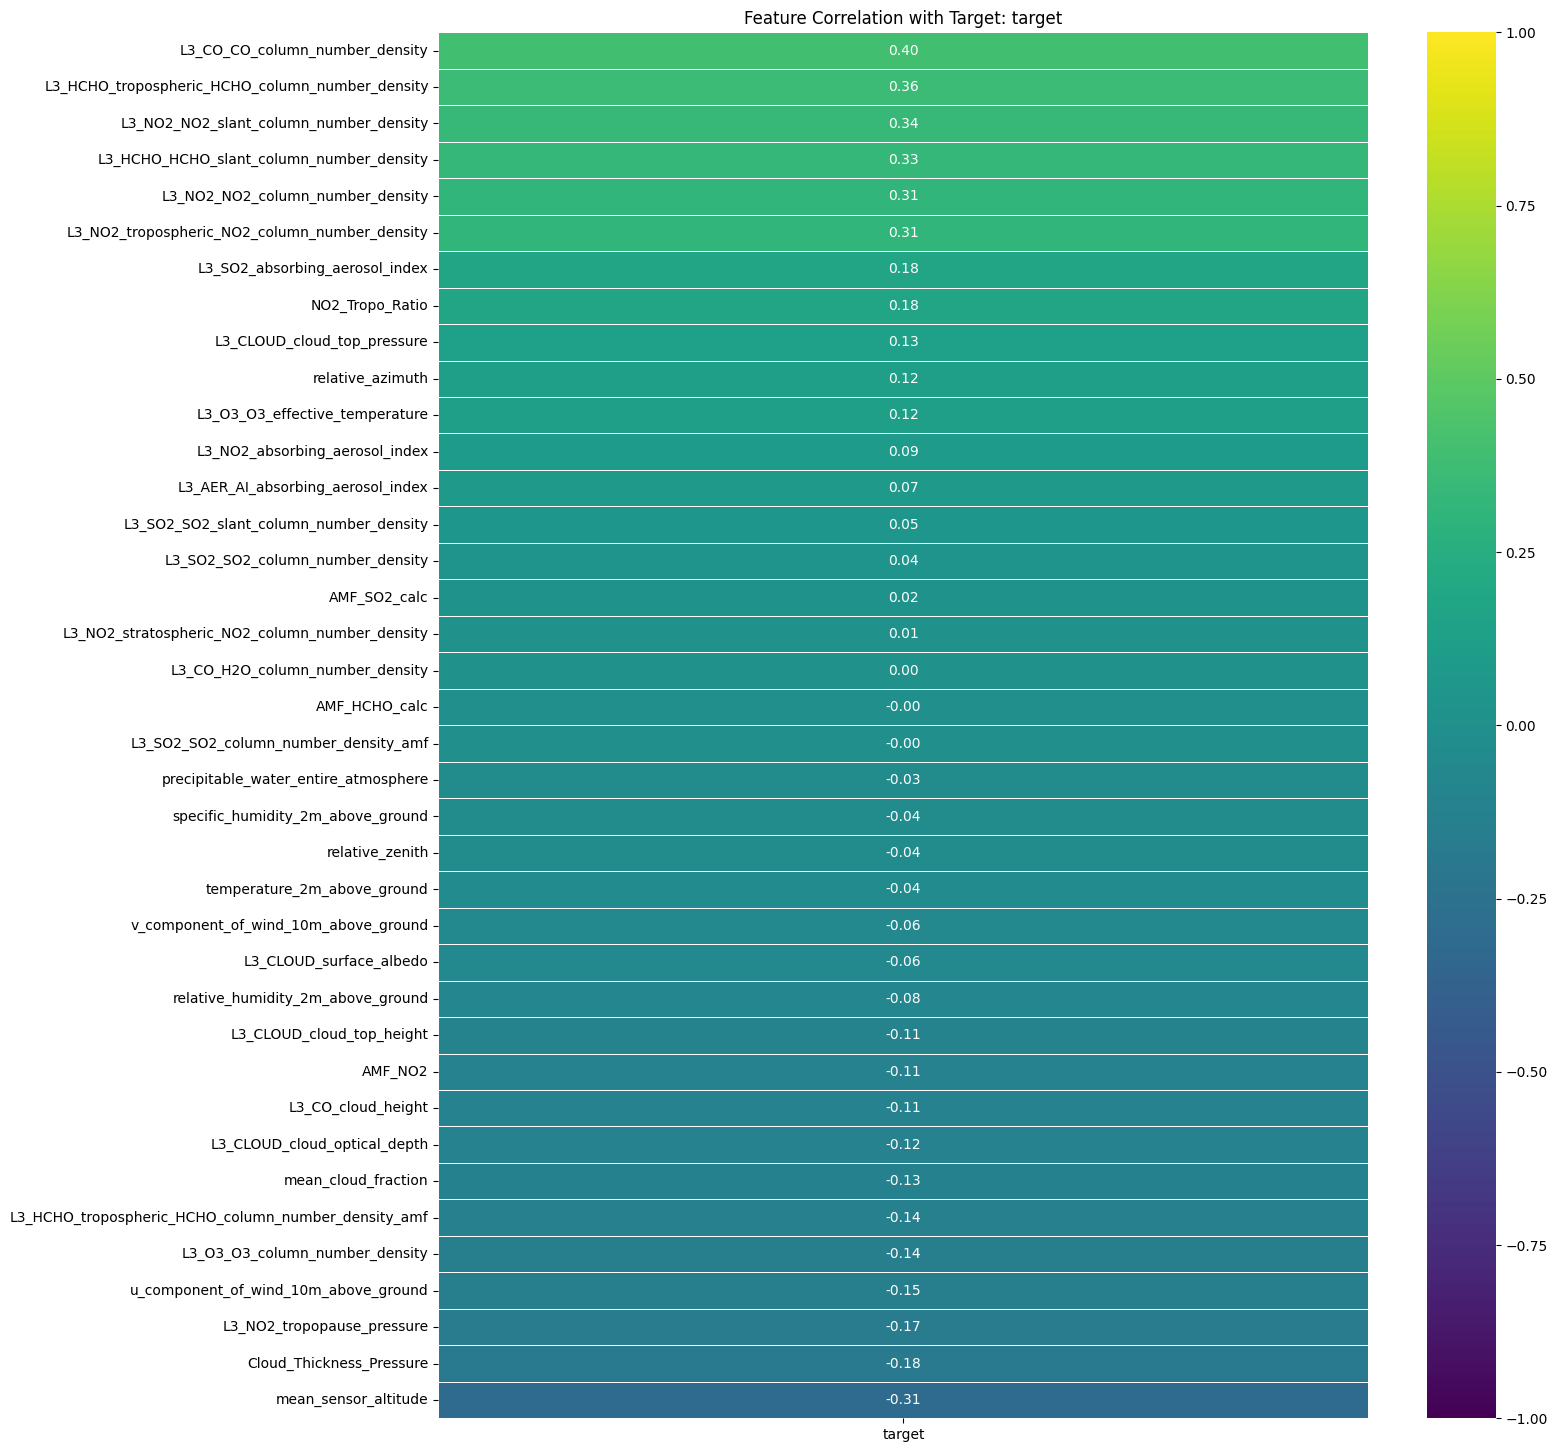

In [43]:
plot_target_correlation(train_df, "target")

# Saving the cleaned data to use for modelling


In [44]:
train_df.to_csv('./../Data/preprocessed/Train_cleaned.csv', index=False)

# Baseline Model

In [ ]:
y = df["target"] 
X = df.drop("target", axis =1)

X_train_val, X_test,y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=RSEED)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=RSEED)

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_train = lin_reg.predict(X_train)
y_pred_val = lin_reg.predict(X_val)

In [ ]:
print(f"The RMSE for train is ", round(root_mean_squared_error(y_train, y_pred_train),3))
print(f"The RMSE for validation is ", round(root_mean_squared_error(y_val, y_pred_val),3))
print(f"The MAE for train is ", round(mean_absolute_error(y_train, y_pred_train),3))
print(f"The MAE for validation is ", round(mean_absolute_error(y_val, y_pred_val),3))
print(f"The R2 for train is ", round(r2_score(y_train, y_pred_train),3))
print(f"The R2 for validation is ", round(r2_score(y_val, y_pred_val),3))